In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import Adam
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import yfinance as yf

In [5]:
def normalize(prices):
    initialPrice = prices.iloc[0]
    return (prices - initialPrice) / initialPrice

tickers = ["AAPL", "MSFT", "GOOG", "NVDA", "ADBE", "ORCL", "INTC", "TXN", "AMD", "PYPL",
           "JPM", "BAC", "C", "GS", "MS", "BRK-A", "V", "MA", "AXP", "BLK",
           "TSLA", "NKE", "HD", "LOW", "SBUX", "MCD", "TGT", "TJX", "LULU", "SONO",
           "GE", "CAT", "BA", "MMM", "HON", "ITW", "UNP", "LMT", "FDX", "RTX",
           "NEE", "DUK", "SO", "D", "AEP", "EXC", "XEL", "SRE", "PEG", "CNP",
           "LLY", "JNJ", "ABBV", "MRK", "PFE", "AMGN", "GILD", "ISRG", "HCA", "UNH",
           "XOM","CVX","COP","EOG","SLB","OXY","DVN","FANG","LNG","HAL",
           "PG","KO","PEP","WMT","COST","CL","KMB","GIS","HSY","MKC",
           "AMT","PLD","EQIX","O","SPG","WELL","DLR","AVB","EQR","VICI",
           "META","NFLX","DIS","TMUS","VZ","T","CHTR","PSKY","CMCSA","WBD"]

timeSeries = yf.download(tickers, start="2019-01-01", auto_adjust="true")["Close"]
tickersUsed = timeSeries.columns.tolist()
normalizedSeries = timeSeries.apply(normalize, axis=0)
target = torch.tensor(normalizedSeries.values.T, dtype=torch.float32).unsqueeze(-1)
nTickers, nTimeSteps, _ = target.shape

[*********************100%***********************]  100 of 100 completed


In [6]:
def normalize(prices):
    initialPrice = prices.iloc[0]
    return (prices - initialPrice) / initialPrice


class lstm(nn.Module):
    def __init__(self, nTickers):
        super().__init__()
        self.hiddenLayers = 128
        self.h0      = nn.Parameter(torch.zeros(nTickers, 128))
        self.lstmCell = nn.LSTMCell(1, 128)
        self.fc      = nn.Linear(128, 1)

    def forward(self, idx, nTimeSteps):
        h = self.h0[idx]
        c = torch.zeros(len(idx), 128)
        x = torch.zeros(len(idx), 1)
        outputs = []
        for i in range(nTimeSteps):
            h, c = self.lstmCell(x, (h, c))
            x    = self.fc(h)
            outputs.append(x)
        return torch.stack(outputs, dim=1)


def plotLoss(lossHistory):
    epochs, losses = zip(*lossHistory)
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, losses, color="steelblue", linewidth=1.2)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Training Loss")
    plt.yscale("log")
    plt.tight_layout()
    plt.show()

    
def plotPCA(model, tickersUsed):
    h0_np = model.h0.detach().numpy()
    h0_2d = PCA(n_components=2).fit_transform(h0_np)
    fig, ax = plt.subplots(figsize=(12, 9))
    for ticker, (x, y) in zip(tickersUsed, h0_2d):
        ax.scatter(x, y, color="steelblue", s=60, alpha=0.75)
        ax.annotate(ticker, (x, y), fontsize=7, alpha=0.85,
                    xytext=(4, 4), textcoords="offset points")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_title("Initial Hidden States h₀ — PCA")
    plt.tight_layout()
    plt.show()

In [ ]:
model     = lstm(nTickers)
optimizer = Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
lossHistory = []

for epoch in range(2000):
    idx  = torch.randperm(nTickers)[:64]
    loss = criterion(model(idx, nTimeSteps), target[idx])
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 5 == 0:
        lossHistory.append((epoch, loss.item()))
        print(f"Epoch {epoch} | Loss: {loss.item():.3f}")

Epoch 0 | Loss: 10.392
Epoch 5 | Loss: 1.399
Epoch 10 | Loss: 11.132
Epoch 15 | Loss: 10.956
Epoch 20 | Loss: 2.457
Epoch 25 | Loss: 10.783
Epoch 30 | Loss: 0.707
Epoch 35 | Loss: 0.873
Epoch 40 | Loss: 2.781
Epoch 45 | Loss: 10.904
Epoch 50 | Loss: 1.317
Epoch 55 | Loss: 2.598
Epoch 60 | Loss: 10.777
Epoch 65 | Loss: 10.913
Epoch 70 | Loss: 10.561
Epoch 75 | Loss: 9.060
Epoch 80 | Loss: 11.025
Epoch 85 | Loss: 9.161
Epoch 90 | Loss: 10.615
Epoch 95 | Loss: 10.944
Epoch 100 | Loss: 10.514
Epoch 105 | Loss: 9.414


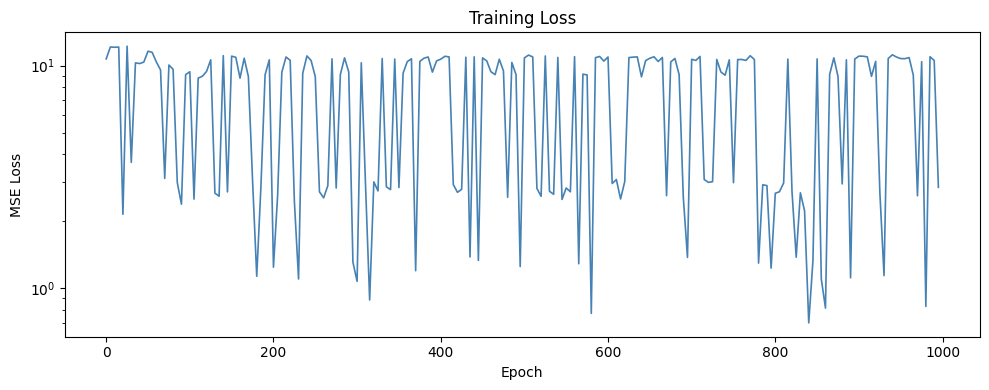

In [9]:
plotLoss(lossHistory)

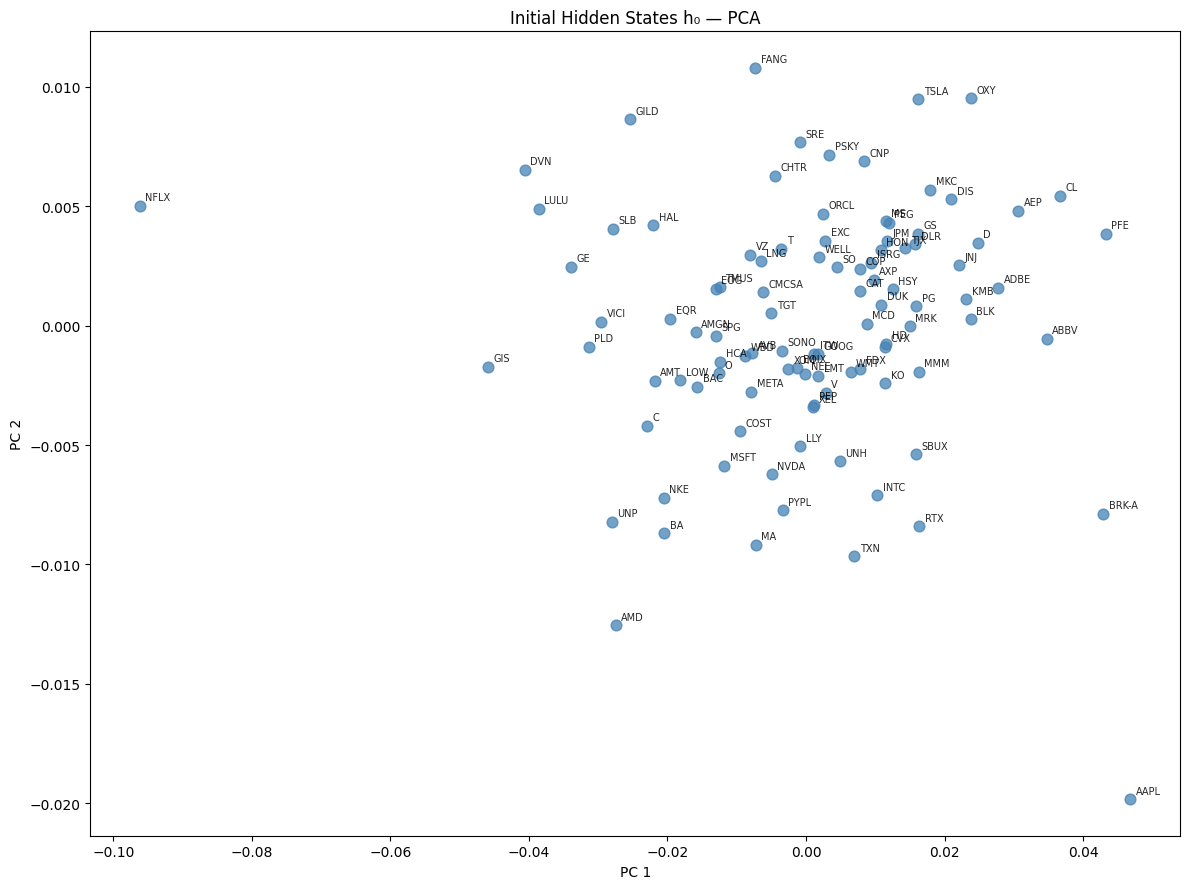

In [10]:
plotPCA(model, tickersUsed)